# Regresi Linear

In [1]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [2]:
# Data Preparation
df = pd.read_excel("../Data Final/Final_PM15-1.xlsx")

In [3]:
# Data Selection
df = df[df['MDS'] <= 100]


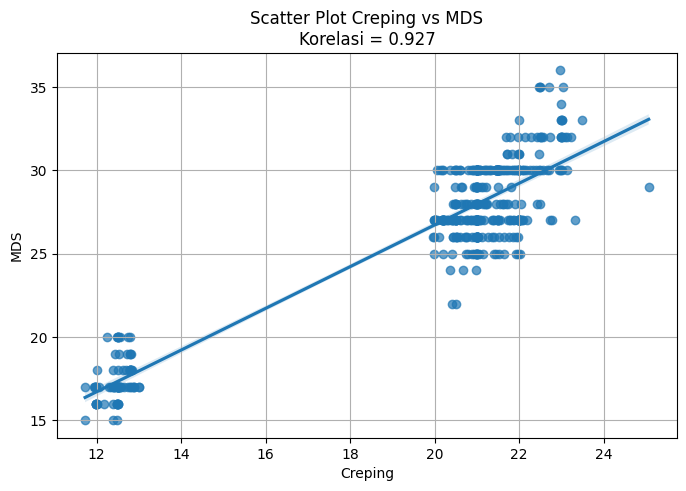

In [4]:
# Hitung korelasi Pearson
corr = df['Mean_Creping'].corr(df['MDS'])

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Mean_Creping'],
    y=df['MDS'],
    scatter_kws={'alpha':0.7}
)

plt.title(f'Scatter Plot Creping vs MDS\nKorelasi = {corr:.3f}')
plt.xlabel('Creping')
plt.ylabel('MDS')

plt.grid(True)
plt.show()

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 439 entries, 0 to 439
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Start_Time                      439 non-null    datetime64[us]
 1   End_Time                        439 non-null    datetime64[us]
 2   Data_Count                      439 non-null    int64         
 3   Mean_Creping                    439 non-null    float64       
 4   Mean_Yankee Speed               439 non-null    float64       
 5   Mean_Pope Reel Speed            439 non-null    float64       
 6   Mean_Yankee Pressure            439 non-null    float64       
 7   Mean_Stock Flow                 439 non-null    float64       
 8   Mean_Stock Consistency          439 non-null    float64       
 9   Mean_Flow Coating               439 non-null    float64       
 10  Mean_Flow Release               439 non-null    float64       
 11  Mean_Jet Wire Ratio   

In [6]:
df['Jenis'] = df['Grade'].apply(lambda x:x.split(' ')[0])
jenis = df['Jenis']
df.groupby(['Jenis'])['Time'].count()

Jenis
FC     25
T     330
TW     84
Name: Time, dtype: int64

## Modelling Linear Regression

In [7]:
# X Variables
features = [
            'Mean_Creping'
]
X = df[features]

# Y Variables
target = 'MDS'
y = df[target]

In [8]:
# Split data train-test
X_train, X_test, y_train, y_test, jenis_train, jenis_test = train_test_split(
    X, 
    y,
    jenis,
    test_size=0.2,
    random_state=42,
    stratify=jenis
)

In [9]:
# --- OPSI 1: Model Tanpa Intercept ---
model_no_const = sm.OLS(y_train, X_train).fit()
# Prediksi
y_pred_no = model_no_const.predict(X_test)
# Evaluasi
mape_no = mean_absolute_percentage_error(y_test, y_pred_no) * 100
r2_no = r2_score(y_test, y_pred_no)

print("--- Model Tanpa Intercept---")
print(f"R-squared: {r2_no:.4f}")
print(f"MAPE: {mape_no:.2f}%")

# --- OPSI 2: Model Dengan Intercept ---
# Tambah konstanta
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)
# Model
model_with_const = sm.OLS(y_train, X_train_const).fit()
# Prediksi
y_pred_with = model_with_const.predict(X_test_const)
# Evaluasi
mape_with = mean_absolute_percentage_error(y_test, y_pred_with) * 100
r2_with = r2_score(y_test, y_pred_with)

print("\n--- Model Dengan Intercept---")
print(f"R-squared: {r2_with:.4f}")
print(f"MAPE: {mape_with:.2f}%")

--- Model Tanpa Intercept---
R-squared: 0.8549
MAPE: 5.52%

--- Model Dengan Intercept---
R-squared: 0.8578
MAPE: 5.51%


In [10]:
# =====================================
# EVALUASI PER JENIS TISU
# =====================================

hasil = []

for jns in jenis_test.unique():

    # Filter data
    mask = jenis_test == jns

    X_test_jns = X_test[mask]
    y_test_jns = y_test[mask]

    # Tambah konstanta
    X_test_jns_const = sm.add_constant(X_test_jns)

    # Prediksi
    y_pred_jns = model_with_const.predict(X_test_jns_const)

    # Evaluasi
    mape = mean_absolute_percentage_error(
        y_test_jns,
        y_pred_jns
    ) * 100

    r2 = r2_score(
        y_test_jns,
        y_pred_jns
    )

    # Simpan hasil
    hasil.append({
        'Jenis': jns,
        'Jumlah_Data': len(y_test_jns),
        'MAPE (%)': round(mape, 2),
        'R-Squared': round(r2, 4)
    })

# DataFrame hasil
hasil_df = pd.DataFrame(hasil)

print("\n===== HASIL PER JENIS =====")
print(hasil_df)


===== HASIL PER JENIS =====
  Jenis  Jumlah_Data  MAPE (%)  R-Squared
0    TW           17      5.34     0.0309
1     T           66      5.10     0.4035
2    FC            5     11.53    -9.0717


In [11]:
print(model_with_const.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     2146.
Date:                Thu, 28 May 2026   Prob (F-statistic):          3.91e-151
Time:                        08:19:26   Log-Likelihood:                -705.21
No. Observations:                 351   AIC:                             1414.
Df Residuals:                     349   BIC:                             1422.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.7425      0.539      3.231   

In [12]:
print(model_no_const.summary())

                                 OLS Regression Results                                
Dep. Variable:                    MDS   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                          7.438e+04
Date:                Thu, 28 May 2026   Prob (F-statistic):                        0.00
Time:                        08:19:26   Log-Likelihood:                         -710.39
No. Observations:                 351   AIC:                                      1423.
Df Residuals:                     350   BIC:                                      1427.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

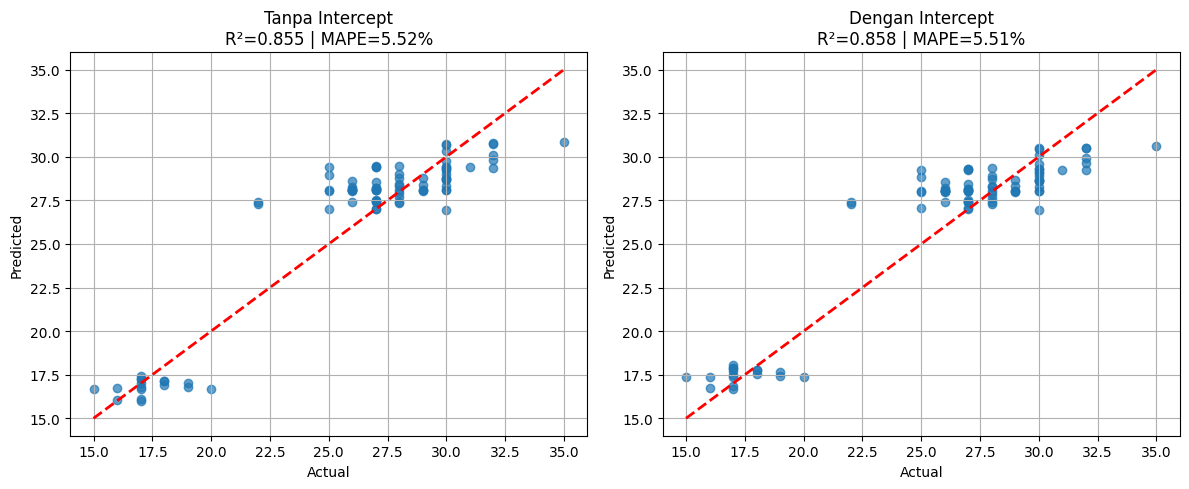

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# =========================
# TANPA INTERCEPT
# =========================
ax[0].scatter(y_test, y_pred_no, alpha=0.7)

ax[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

ax[0].set_title(
    f'Tanpa Intercept\nR²={r2_no:.3f} | MAPE={mape_no:.2f}%'
)

ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")
ax[0].grid(True)

# =========================
# DENGAN INTERCEPT
# =========================
ax[1].scatter(y_test, y_pred_with, alpha=0.7)

ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

ax[1].set_title(
    f'Dengan Intercept\nR²={r2_with:.3f} | MAPE={mape_with:.2f}%'
)

ax[1].set_xlabel("Actual")
ax[1].set_ylabel("Predicted")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
print("Min. Creping:", X['Mean_Creping'].min())
print("Max. Creping:", X['Mean_Creping'].max())
print("Min. MDS:", y.min())
print("Max. MDS:", y.max())

Min. Creping: 11.729025
Max. Creping: 25.06922
Min. MDS: 15
Max. MDS: 36


### Import Model

In [15]:
import joblib
import os

# Folder model
os.makedirs("models/PM15/MDS", exist_ok=True)

# Simpan model
joblib.dump(model_with_const, "models/PM15/MDS/model.pkl")

# Simpan fitur
joblib.dump(features, "models/PM15/MDS/features.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [16]:
DW = sm.stats.durbin_watson(model_with_const.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.8375789033745826
Tidak ada autokorelasi (baik positif maupun negatif)


### Indentik (Heterokesdastisitas)

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (varians residual konstan)
# H1: Terjadi heteroskedastisitas

bp_test = het_breuschpagan(
    model_with_const.resid,
    model_with_const.model.exog
)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
results = dict(zip(labels, bp_test))

print(results)

if results['LM-Test p-value'] < 0.05:
    print('Terjadi heteroskedastisitas')
else:
    print('Tidak terjadi heteroskedastisitas')


{'LM Statistic': np.float64(24.653104571604594), 'LM-Test p-value': np.float64(6.863409818598177e-07), 'F-Statistic': np.float64(26.364379793457598), 'F-Test p-value': np.float64(4.708058942778013e-07)}
Terjadi heteroskedastisitas


### Normalitas

In [18]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

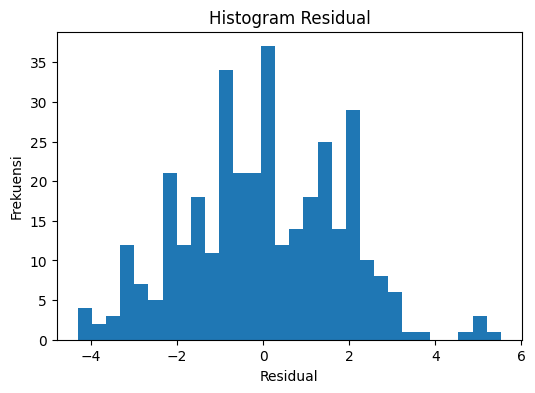

In [19]:
# Histogram Residual
plt.figure(figsize=(6,4))
plt.hist(model_with_const.resid, bins=30)
plt.title("Histogram Residual")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()


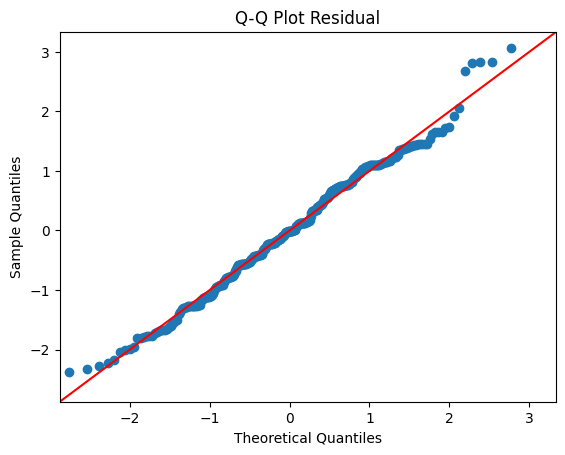

In [20]:
# Q-Q Plot Residual
sm.qqplot(model_with_const.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()


In [21]:
# Uji Statistik Shapiro-Wilk
# H0: Residual berdistribusi normal
# H1: Residual tidak berdistribusi normal

stat, p_value = stats.shapiro(model_with_const.resid)

print(f"Shapiro-Wilk Test p-value = {p_value:.6f}")

if p_value < 0.05:
    print('Residual tidak berdistribusi normal')
else:
    print('Residual berdistribusi normal')


Shapiro-Wilk Test p-value = 0.024895
Residual tidak berdistribusi normal


### Multikolinearitas

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

ValueError: zero-size array to reduction operation maximum which has no identity